---
#  LAYER 1 — Data Ingestion

In [ ]:
pip install pandas openpyxl scikit-learn rapidfuzz matplotlib seaborn numpy


Note: you may need to restart the kernel to use updated packages.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  UPDATE THIS PATH to your Excel file location
# ─────────────────────────────────────────────────────────────────────────────
EXCEL_FILE = r"C:\Users\Nandni\Desktop\Workshop\Excel1 Invoice Anomaly Dataset.xlsx"

import pandas as pd

print(" Loading all sheets...")
all_sheets = pd.read_excel(EXCEL_FILE, sheet_name=None, header=None)
print("Sheets found:", list(all_sheets.keys()))

def load_sheet(name, skip_top=0):
    return pd.read_excel(EXCEL_FILE, sheet_name=name, skiprows=skip_top)

df_po    = load_sheet('PO Register',                   skip_top=0)
df_grn   = load_sheet('GRN Register',                  skip_top=2)
df_inv   = load_sheet('Invoice Register (Problem)',     skip_top=2)
df_rate  = load_sheet('Rate Card Master',               skip_top=2)
df_gt    = load_sheet('ANSWER KEY (Ground Truth)',      skip_top=3)

# Strip column names
for df in [df_po, df_grn, df_inv, df_rate, df_gt]:
    df.columns = df.columns.str.strip()

df_grn  = df_grn.dropna(how='all', axis=1)
df_inv  = df_inv.dropna(subset=['Invoice No'])
df_gt   = df_gt.dropna(subset=['Invoice Number'])

print(f"\n PO Register      : {df_po.shape}")
print(f" GRN Register     : {df_grn.shape}")
print(f" Invoice Register : {df_inv.shape}")
print(f" Rate Card Master : {df_rate.shape}")
print(f" Ground Truth     : {df_gt.shape}")

 Loading all sheets...
Sheets found: ['README', 'PO Register', 'GRN Register', 'Invoice Register (Problem)', 'Rate Card Master', 'ANSWER KEY (Ground Truth)']

 PO Register      : (200, 15)
 GRN Register     : (185, 13)
 Invoice Register : (501, 20)
 Rate Card Master : (60, 13)
 Ground Truth     : (141, 6)


In [6]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── ML Libraries ────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.cluster import DBSCAN

# ── Fuzzy Matching ───────────────────────────────────────────────────────────
try:
    from rapidfuzz import fuzz, process
    RAPIDFUZZ = True
    print(" rapidfuzz loaded — fuzzy vendor matching enabled")
except ImportError:
    RAPIDFUZZ = False
    print("  rapidfuzz not found. Run: pip install rapidfuzz")

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print(" All libraries ready")

 rapidfuzz loaded — fuzzy vendor matching enabled
 All libraries ready


---
#  LAYER 2 — Data Cleaning

In [7]:
# ── Date Normalization ───────────────────────────────────────────────────────
# Handles: DD-MM-YYYY | MM/DD/YYYY | YYYY-MM-DD | Excel serial numbers

def parse_date(val):
    if pd.isna(val): return pd.NaT
    if isinstance(val, (int, float)):
        try: return pd.Timestamp('1899-12-30') + pd.Timedelta(days=int(val))
        except: return pd.NaT
    val = str(val).strip()
    for fmt in ["%d-%m-%Y", "%m/%d/%Y", "%Y-%m-%d", "%d/%m/%Y"]:
        try: return pd.to_datetime(val, format=fmt)
        except: continue
    return pd.to_datetime(val, errors='coerce')

# Apply date parsing
for col in ['Invoice Date', 'Receipt Date', 'Due Date']:
    if col in df_inv.columns: df_inv[col] = df_inv[col].apply(parse_date)

for col in ['PO Date', 'Delivery Date']:
    if col in df_po.columns: df_po[col] = df_po[col].apply(parse_date)

for col in ['GRN Date']:
    if col in df_grn.columns: df_grn[col] = df_grn[col].apply(parse_date)

print(" Dates normalized")

 Dates normalized


In [8]:
# ── Vendor Name Standardization (Fuzzy Matching for V003, V007 variants) ────

canonical = df_po[['Vendor ID','Vendor Name']].drop_duplicates('Vendor ID')\
                 .set_index('Vendor ID')['Vendor Name'].to_dict()

def clean_vendor(row):
    vid  = str(row.get('Vendor ID', '')).strip()
    name = str(row.get('Vendor Name', '')).strip()
    if vid in canonical:
        return canonical[vid]
    if RAPIDFUZZ:
        match = process.extractOne(name, list(canonical.values()), scorer=fuzz.ratio)
        if match and match[1] >= 80:
            return match[0]
    return name

df_inv['Vendor Name Clean'] = df_inv.apply(clean_vendor, axis=1)

# Numeric coercion
for col in ['Qty Billed', 'Rate Billed (Rs.)', 'Basic Amt (Rs.)', 'GST %', 'GST Amt (Rs.)', 'Total Invoice (Rs.)']:
    if col in df_inv.columns:
        df_inv[col] = pd.to_numeric(df_inv[col], errors='coerce')

df_inv = df_inv.reset_index(drop=True)
print(f" Vendor names standardized | Invoice count: {len(df_inv)}")
print("\nSample cleaned vendors:")
print(df_inv[['Vendor ID','Vendor Name','Vendor Name Clean']].drop_duplicates('Vendor ID').to_string(index=False))

 Vendor names standardized | Invoice count: 501

Sample cleaned vendors:
Vendor ID        Vendor Name  Vendor Name Clean
     V001 Sharma Enterprises Sharma Enterprises
     V002 Rajput Steel Works Rajput Steel Works
     V003    Gupta Packaging    Gupta Packaging
     V004    Singh Logistics    Singh Logistics
     V005   Mehta Industries   Mehta Industries
     V006   Joshi Components   Joshi Components
     V007     Agarwal Metals     Agarwal Metals
     V008    Patel Suppliers    Patel Suppliers
     V009      Kumar Trading      Kumar Trading
     V010   Verma Auto Parts   Verma Auto Parts
      NaN                NaN                nan


---
#  Exploratory Data Analysis

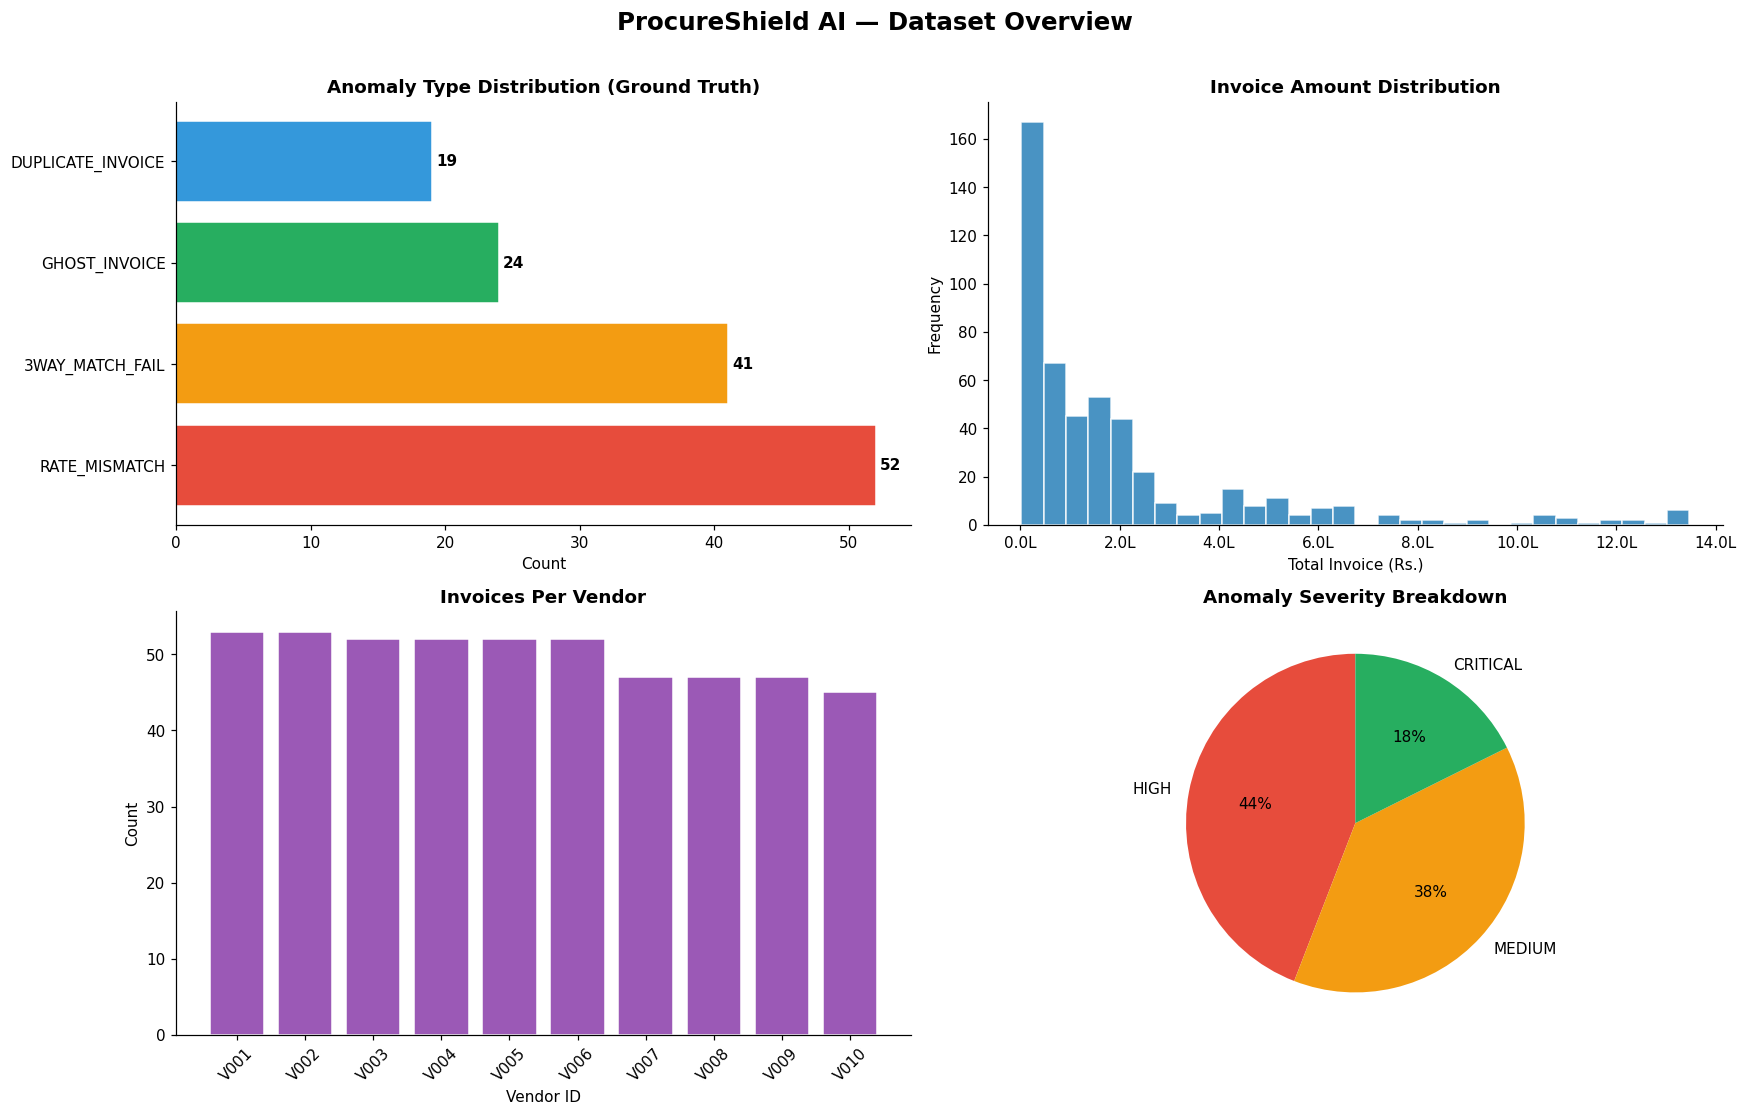


 Dataset Summary
  Invoices   : 501
  POs        : 200
  GRNs       : 185
  Rate Cards : 60
  GT Labels  : 141
  Total Value: Rs. 102,626,667


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ProcureShield AI — Dataset Overview', fontsize=16, fontweight='bold', y=1.01)

# 1. Anomaly distribution
anomaly_counts = df_gt['Anomaly Type'].value_counts()
colors = ['#e74c3c','#f39c12','#27ae60','#3498db']
axes[0,0].barh(anomaly_counts.index, anomaly_counts.values, color=colors, edgecolor='white')
axes[0,0].set_title('Anomaly Type Distribution (Ground Truth)', fontweight='bold')
axes[0,0].set_xlabel('Count')
for i, v in enumerate(anomaly_counts.values):
    axes[0,0].text(v+0.3, i, str(v), va='center', fontweight='bold')

# 2. Invoice amount distribution
amt = df_inv['Total Invoice (Rs.)'].dropna()
axes[0,1].hist(amt, bins=30, color='#2980b9', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Invoice Amount Distribution', fontweight='bold')
axes[0,1].set_xlabel('Total Invoice (Rs.)')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e5:.1f}L'))
axes[0,1].set_ylabel('Frequency')
# 3. Invoices per vendor
vc = df_inv['Vendor ID'].value_counts()
axes[1,0].bar(vc.index.astype(str), vc.values, color='#9b59b6', edgecolor='white')
axes[1,0].set_title('Invoices Per Vendor', fontweight='bold')
axes[1,0].set_xlabel('Vendor ID')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Severity breakdown
if 'Severity' in df_gt.columns:
    sev = df_gt['Severity'].value_counts()
    axes[1,1].pie(sev.values, labels=sev.index, autopct='%1.0f%%',
                  colors=['#e74c3c','#f39c12','#27ae60'], startangle=90)
    axes[1,1].set_title('Anomaly Severity Breakdown', fontweight='bold')
else:
    axes[1,1].text(0.5, 0.5, 'Severity\nNot Available', ha='center', va='center',
                   fontsize=14, transform=axes[1,1].transAxes)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary stats
print("\n Dataset Summary")
print(f"  Invoices   : {len(df_inv)}")
print(f"  POs        : {len(df_po)}")
print(f"  GRNs       : {len(df_grn)}")
print(f"  Rate Cards : {len(df_rate)}")
print(f"  GT Labels  : {len(df_gt)}")
total = df_inv['Total Invoice (Rs.)'].sum()
print(f"  Total Value: Rs. {total:,.0f}")

---
#  LAYER 3 — Feature Engineering
Converting raw procurement data into anomaly detection signals.

In [10]:
# ── Build lookup dictionaries ────────────────────────────────────────────────

valid_pos = set(df_po['PO Number'].astype(str).str.strip())

# Rate Card: (Vendor ID, Item Description lower) → Agreed Rate
rate_lookup = {}
if all(c in df_rate.columns for c in ['Vendor ID', 'Item Description', 'Agreed Rate (Rs.)']):
    for _, r in df_rate.iterrows():
        k = (str(r['Vendor ID']).strip(), str(r['Item Description']).strip().lower())
        rate_lookup[k] = pd.to_numeric(r['Agreed Rate (Rs.)'], errors='coerce')

# PO lookups: PO Number → Agreed Rate and Qty Ordered
# Also build vendor+item → agreed rate for items not in Rate Card (e.g. Ball Bearings, Hydraulic Hoses)
po_rate      = {}
po_qty       = {}
po_rate_item = {}
if 'PO Number' in df_po.columns:
    for _, r in df_po.iterrows():
        pn   = str(r['PO Number']).strip()
        vid  = str(r['Vendor ID']).strip()
        item = str(r.get('Item Description', '')).strip().lower()
        rate = pd.to_numeric(r.get('Agreed Rate (Rs.)', np.nan), errors='coerce')
        qty  = pd.to_numeric(r.get('Qty Ordered', np.nan), errors='coerce')
        po_rate[pn] = rate
        po_qty[pn]  = qty
        if (vid, item) not in po_rate_item and pd.notna(rate):
            po_rate_item[(vid, item)] = rate

# GRN qty: PO Reference → total Qty Accepted
grn_qty = {}
if 'PO Reference' in df_grn.columns and 'Qty Accepted' in df_grn.columns:
    _grn_clean = df_grn[df_grn['PO Reference'].fillna('').astype(str).str.strip() != '']
    grn_qty = _grn_clean.groupby('PO Reference')['Qty Accepted'].sum().to_dict()

# GRN date: PO Reference → earliest GRN Date
# Used by feature engineering (grn_date) AND 3-way temporal check (grn_date_by_po)
grn_date_by_po = {}
if 'PO Reference' in df_grn.columns and 'GRN Date' in df_grn.columns:
    _grn_clean2 = df_grn[df_grn['PO Reference'].fillna('').astype(str).str.strip() != '']
    grn_date_by_po = _grn_clean2.groupby('PO Reference')['GRN Date'].min().to_dict()

grn_date = grn_date_by_po  # alias used by compute_features below

# Vendor invoice history for frequency features
df_inv_sorted = df_inv.sort_values('Invoice Date').reset_index(drop=True)

print(" Lookups built")
print(f"   Rate card entries    : {len(rate_lookup)}")
print(f"   PO rate entries      : {len(po_rate)}")
print(f"   PO rate item entries : {len(po_rate_item)}")
print(f"   GRN date entries     : {len(grn_date_by_po)}")
print(f"   GRN qty entries      : {len(grn_qty)}")


 Lookups built
   Rate card entries    : 60
   PO rate entries      : 200
   PO rate item entries : 10
   GRN date entries     : 137
   GRN qty entries      : 137


In [11]:
# ── Compute All Features ─────────────────────────────────────────────────────

def compute_features(df):
    feats = []
    
    # Pre-compute vendor frequency per 30-day window
    df = df.copy().sort_values('Invoice Date').reset_index(drop=True)
    
    for i, row in df.iterrows():
        vid          = str(row.get('Vendor ID', '')).strip()
        po_ref       = str(row.get('PO Reference', '')).strip()
        grn_ref      = str(row.get('GRN Reference', '')).strip()
        item         = str(row.get('Item Description', '')).strip().lower()
        inv_date     = row.get('Invoice Date')
        inv_qty      = pd.to_numeric(row.get('Qty Billed'), errors='coerce')
        rate_billed  = pd.to_numeric(row.get('Rate Billed (Rs.)'), errors='coerce')
        total_amt    = pd.to_numeric(row.get('Total Invoice (Rs.)'), errors='coerce')
        inv_no       = str(row.get('Invoice No', ''))

        # ── F1: rate_deviation_pct (vs Rate Card) ──────────────────────────
        key = (vid, item)
        agreed = rate_lookup.get(key, np.nan)
        if pd.notna(agreed) and agreed > 0 and pd.notna(rate_billed):
            rate_dev = (rate_billed - agreed) / agreed * 100
        else:
            po_agreed = po_rate.get(po_ref, np.nan)
            rate_dev  = (rate_billed - po_agreed) / po_agreed * 100 \
                        if pd.notna(po_agreed) and po_agreed > 0 and pd.notna(rate_billed) else 0.0

        # ── F2: qty_vs_grn_pct ─────────────────────────────────────────────
        grn_q = grn_qty.get(po_ref, np.nan)
        qty_grn_pct = ((inv_qty - grn_q) / grn_q * 100) \
                      if pd.notna(grn_q) and grn_q > 0 and pd.notna(inv_qty) else 0.0

        # ── F3: has_po_reference ───────────────────────────────────────────
        has_po = 1 if po_ref in valid_pos else 0

        # ── F4: has_grn_reference ──────────────────────────────────────────
        has_grn = 0 if (grn_ref in ['', 'nan', 'None', 'N/A', '-'] or pd.isna(row.get('GRN Reference'))) else 1

        # ── F5: invoice_before_delivery ────────────────────────────────────
        grn_d = grn_date.get(po_ref, pd.NaT)
        inv_before_del = 0
        if pd.notna(inv_date) and pd.notna(grn_d):
            inv_before_del = 1 if pd.Timestamp(inv_date) < pd.Timestamp(grn_d) else 0

        # ── F6: vendor_invoice_frequency (last 30 days) ────────────────────
        freq = 0
        if pd.notna(inv_date):
            window_start = pd.Timestamp(inv_date) - pd.Timedelta(days=30)
            vendor_inv   = df[(df['Vendor ID'].astype(str).str.strip() == vid) &
                              (df['Invoice Date'] >= window_start) &
                              (df['Invoice Date'] < pd.Timestamp(inv_date))]
            freq = len(vendor_inv)

        # ── F7: days_since_last_invoice ────────────────────────────────────
        days_gap = 999
        if pd.notna(inv_date):
            prev = df[(df['Vendor ID'].astype(str).str.strip() == vid) &
                      (df['Invoice Date'] < pd.Timestamp(inv_date))]['Invoice Date']
            if len(prev) > 0:
                days_gap = (pd.Timestamp(inv_date) - prev.max()).days

        # ── F8: same_invoice_number_flag ───────────────────────────────────
        dup_flag = 1 if df['Invoice No'].astype(str).str.strip().tolist().count(inv_no) > 1 else 0

        # ── F9: amount_similarity_score ────────────────────────────────────
        # Count invoices from same vendor with amount within ±5%
        similar_amt = 0
        if pd.notna(total_amt) and total_amt > 0:
            others = df[(df['Vendor ID'].astype(str).str.strip() == vid) &
                        (df.index != i)]['Total Invoice (Rs.)']
            others_num = pd.to_numeric(others, errors='coerce').dropna()
            similar_amt = int(((others_num - total_amt).abs() / total_amt < 0.05).sum())

        # ── F10: rate_card_match ───────────────────────────────────────────
        rc_match = 0
        if pd.notna(agreed) and pd.notna(rate_billed) and agreed > 0:
            rc_match = 1 if abs(rate_billed - agreed) / agreed <= 0.03 else 0

        # ── F11: qty_vs_po_pct ─────────────────────────────────────────────
        po_q = po_qty.get(po_ref, np.nan)
        qty_po_pct = ((inv_qty - po_q) / po_q * 100) \
                     if pd.notna(po_q) and po_q > 0 and pd.notna(inv_qty) else 0.0

        # ── Categorical encodings ──────────────────────────────────────────
        vendor_enc    = hash(vid) % 100
        pay_terms_enc = hash(str(row.get('Payment Terms', ''))) % 10
        sub_via_enc   = hash(str(row.get('Submitted Via', ''))) % 10

        # ── Date features ──────────────────────────────────────────────────
        inv_month = pd.Timestamp(inv_date).month if pd.notna(inv_date) else 0
        inv_dow   = pd.Timestamp(inv_date).dayofweek if pd.notna(inv_date) else 0
        inv_qtr   = pd.Timestamp(inv_date).quarter if pd.notna(inv_date) else 0

        # ── Financial consistency ──────────────────────────────────────────
        gst_pct  = pd.to_numeric(row.get('GST %'), errors='coerce') or 0
        gst_amt  = pd.to_numeric(row.get('GST Amt (Rs.)'), errors='coerce') or 0
        basic    = pd.to_numeric(row.get('Basic Amt (Rs.)'), errors='coerce') or 0
        exp_gst  = basic * gst_pct / 100
        gst_diff = abs(gst_amt - exp_gst) if exp_gst > 0 else 0

        feats.append({
            'Invoice No'               : inv_no,
            'rate_deviation_pct'       : rate_dev,
            'qty_vs_grn_pct'           : qty_grn_pct,
            'qty_vs_po_pct'            : qty_po_pct,
            'has_po_reference'         : has_po,
            'has_grn_reference'        : has_grn,
            'invoice_before_delivery'  : inv_before_del,
            'vendor_invoice_frequency' : freq,
            'days_since_last_invoice'  : min(days_gap, 999),
            'same_invoice_number_flag' : dup_flag,
            'amount_similarity_score'  : similar_amt,
            'rate_card_match'          : rc_match,
            'gst_diff'                 : gst_diff,
            'total_invoice_amt'        : total_amt or 0,
            'qty_billed'               : inv_qty or 0,
            'rate_billed'              : rate_billed or 0,
            'vendor_enc'               : vendor_enc,
            'pay_terms_enc'            : pay_terms_enc,
            'sub_via_enc'              : sub_via_enc,
            'inv_month'                : inv_month,
            'inv_day_of_week'          : inv_dow,
            'inv_quarter'              : inv_qtr,
        })
    
    return pd.DataFrame(feats)

print(" Computing features for all invoices... (may take ~30 sec)")
df_feat = compute_features(df_inv)
df_feat = df_feat.fillna(0)

FEATURE_COLS = [c for c in df_feat.columns if c != 'Invoice No']
print(f"\n Feature matrix: {df_feat[FEATURE_COLS].shape}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

 Computing features for all invoices... (may take ~30 sec)

 Feature matrix: (501, 21)
Features (21): ['rate_deviation_pct', 'qty_vs_grn_pct', 'qty_vs_po_pct', 'has_po_reference', 'has_grn_reference', 'invoice_before_delivery', 'vendor_invoice_frequency', 'days_since_last_invoice', 'same_invoice_number_flag', 'amount_similarity_score', 'rate_card_match', 'gst_diff', 'total_invoice_amt', 'qty_billed', 'rate_billed', 'vendor_enc', 'pay_terms_enc', 'sub_via_enc', 'inv_month', 'inv_day_of_week', 'inv_quarter']


---
#  LAYER 4 — Fraud Detection Modules
Four specialized detectors — each produces a **module risk score (0–100)**.

In [12]:
# ════════════════════════════════════════════════════════════════════════════
#  MODULE 1: DUPLICATE INVOICE DETECTION
#
#  Two types of duplicates in this dataset:
#    Type A — Exact duplicate: same Invoice No submitted twice (19 cases)
#    Type B — Revised invoice: -R suffix resubmission (9 cases)
#              e.g. INV/V001/59373-R is a resubmission of INV/V001/59373
#  Fix: -R invoices now score +60 (same as exact dup), not just +25
# ════════════════════════════════════════════════════════════════════════════

def detect_duplicates(df, feat):
    scores  = np.zeros(len(df))
    inv_nos = df['Invoice No'].astype(str).str.strip().tolist()

    for i, row in df.iterrows():
        score  = 0
        inv_no = str(row.get('Invoice No', '')).strip()
        vid    = str(row.get('Vendor ID', '')).strip()
        po_ref = str(row.get('PO Reference', '')).strip()

        # Signal 1: Exact duplicate invoice number (+60)
        if inv_nos.count(inv_no) > 1:
            score += 60

        # Signal 2: Revised invoice (-R suffix) with base invoice present (+60)
        if inv_no.endswith('-R') and inv_no[:-2] in inv_nos:
            score += 60

        # Signal 3: Same vendor + same PO billed more than once (+20)
        same_po_vendor = df[
            (df['Vendor ID'].astype(str).str.strip() == vid) &
            (df['PO Reference'].astype(str).str.strip() == po_ref) &
            (df.index != i)
        ]
        if len(same_po_vendor) > 0:
            score += 20

        scores[i] = min(score, 100)

    return scores

print(" Running Module 1: Duplicate Detection...")
dup_scores = detect_duplicates(df_inv, df_feat)
df_inv['dup_score'] = dup_scores
print(f" Duplicates flagged (score > 50): {(dup_scores > 50).sum()}  ")


 Running Module 1: Duplicate Detection...
 Duplicates flagged (score > 50): 29  


In [13]:
# ════════════════════════════════════════════════════════════════════════════
#  MODULE 2: RATE MISMATCH DETECTION
#
#  Fix: V007 (Ball Bearings), V008 (Hydraulic Hoses), V009 (Safety Gloves),
#  V010 (Welding Rods) are NOT in the Rate Card — it only has ITM001-ITM006.
#  Previous code returned NaN for these → 20 of 52 mismatches were missed.
#  Fix: 3-level fallback: Rate Card → PO vendor+item history → specific PO rate
# ════════════════════════════════════════════════════════════════════════════

def detect_rate_mismatch(df, feat):
    scores = np.zeros(len(df))

    for i, row in df.iterrows():
        vid    = str(row.get('Vendor ID', '')).strip()
        po_ref = str(row.get('PO Reference', '')).strip()
        item   = str(row.get('Item Description', '')).strip().lower()
        rate_b = pd.to_numeric(row.get('Rate Billed (Rs.)'), errors='coerce')

        if pd.isna(rate_b):
            continue

        score = 0

        # Level 1: Rate Card lookup
        rc_rate = rate_lookup.get((vid, item), np.nan)
        # Level 2: PO vendor+item history (items not in Rate Card)
        if pd.isna(rc_rate):
            rc_rate = po_rate_item.get((vid, item), np.nan)
        # Level 3: Specific PO agreed rate
        if pd.isna(rc_rate):
            rc_rate = po_rate.get(po_ref, np.nan)

        if pd.notna(rc_rate) and rc_rate > 0:
            dev = (rate_b - rc_rate) / rc_rate
            if dev > 0.20:   score += 80
            elif dev > 0.10: score += 60
            elif dev > 0.03: score += 40

        scores[i] = min(score, 100)

    return scores

rate_scores = detect_rate_mismatch(df_inv, df_feat)
df_inv['rate_score'] = rate_scores
print(f" Rate mismatches flagged (score > 30): {(rate_scores > 30).sum()} ")


 Rate mismatches flagged (score > 30): 52 


In [14]:
# ════════════════════════════════════════════════════════════════════════════
#  MODULE 3: GHOST INVOICE DETECTION
#  Indicators: Missing PO | Missing GRN | New vendor | Abnormal amount
# ════════════════════════════════════════════════════════════════════════════

# Compute per-vendor amount stats for outlier detection
vendor_amt_stats = df_inv.groupby('Vendor ID')['Total Invoice (Rs.)'].agg(['mean','std']).to_dict('index')
known_vendors = set(df_po['Vendor ID'].astype(str).str.strip().unique())

valid_grn_refs = set(df_grn['GRN Number'].astype(str).str.strip().unique()) \
                 if 'GRN Number' in df_grn.columns else set()

def detect_ghost(df):
    scores = np.zeros(len(df))
    
    for i, row in df.iterrows():
        score  = 0
        po_ref = str(row.get('PO Reference', '')).strip()
        grn_r  = str(row.get('GRN Reference', '')).strip()
        vid    = str(row.get('Vendor ID', '')).strip()
        amt    = pd.to_numeric(row.get('Total Invoice (Rs.)'), errors='coerce')
        
        # No PO reference (+45)
        no_po = po_ref in ['', 'nan', 'None', 'N/A', '-'] or po_ref not in valid_pos
        if no_po: score += 45
        
        # No GRN reference (+25)
        no_grn = grn_r in ['', 'nan', 'None', 'N/A', '-']
        if no_grn: score += 25
        
        # New vendor not in PO register (+20)
        if vid not in known_vendors: score += 20
        
        # Abnormal invoice amount (>2σ from vendor mean) (+10)
        stats = vendor_amt_stats.get(vid, {})
        if stats and pd.notna(amt) and pd.notna(stats.get('std')) and stats['std'] > 0:
            z = abs(amt - stats['mean']) / stats['std']
            if z > 2: score += 10
        
        scores[i] = min(score, 100)
    
    return scores

ghost_scores = detect_ghost(df_inv)
df_inv['ghost_score'] = ghost_scores
print(f" Ghost invoices flagged (score > 40): {(ghost_scores > 40).sum()} ")

 Ghost invoices flagged (score > 40): 25 


In [15]:
# ════════════════════════════════════════════════════════════════════════════
#  MODULE 4: 3-WAY MATCH FAILURE
#
#  Two types of 3-way failures:
#    Type A — Qty overbilling: invoice qty > PO ordered qty (25 cases)
#    Type B — Temporal: invoice submitted before goods received (16 cases)
#
#  Fix: old code summed ALL GRN qty for a PO (same PO reused across 500 invoices
#  → summed GRN qty >> any single invoice qty → 85+ false positives on normal invoices).
#
#  Corrected approach:
#    Qty check  : inv_qty > po_qty (positive deviation = overbilling, no abs())
#    Temporal   : only when GRN Reference is MISSING from invoice
#                 (vendor submitted before GRN was created for that PO)
# ════════════════════════════════════════════════════════════════════════════

MATCH_TOL = 0.05  # 5% tolerance

def detect_three_way(df):
    scores = np.zeros(len(df))

    for i, row in df.iterrows():
        po_ref  = str(row.get('PO Reference', '  ')).strip()
        grn_ref = str(row.get('GRN Reference', '  ')).strip()
        inv_q   = pd.to_numeric(row.get('Qty Billed'), errors='coerce')
        inv_d   = row.get('Invoice Date')
        score   = 0

        if pd.isna(inv_q) or po_ref not in valid_pos:
            scores[i] = 0
            continue

        # Check 1: Qty overbilling — invoice billed MORE than PO ordered qty
        po_q = po_qty.get(po_ref, np.nan)
        if pd.notna(po_q) and po_q > 0:
            dev = (inv_q - po_q) / po_q   # signed: positive = overbilled
            if dev > 0.20:        score += 70
            elif dev > MATCH_TOL: score += 40

        # Check 2: Invoice date BEFORE goods were received
        # Only fires when GRN Reference is missing (submitted pre-delivery)
        if grn_ref in ['', 'nan', 'None', 'N/A', '-']:
            grn_d = grn_date_by_po.get(po_ref, pd.NaT)
            if pd.notna(inv_d) and pd.notna(grn_d):
                try:
                    if pd.Timestamp(inv_d) < pd.Timestamp(grn_d):
                        score += 50
                except Exception:
                    pass

        scores[i] = min(score, 100)

    return scores

match_scores = detect_three_way(df_inv)
df_inv['match_score'] = match_scores
print(f" 3-Way match failures (score > 25): {(match_scores > 25).sum()} ")


 3-Way match failures (score > 25): 33 


---
#  LAYER 5 — Risk Scoring System
Combine all four module scores into a **Final Risk Score (0–100)**.

In [16]:
# ── Weighted Risk Score ──────────────────────────────────────────────────────

W_DUP   = 0.30
W_RATE  = 0.25
W_GHOST = 0.30
W_MATCH = 0.15

df_inv['risk_score'] = (
    df_inv['dup_score']   * W_DUP  +
    df_inv['rate_score']  * W_RATE +
    df_inv['ghost_score'] * W_GHOST +
    df_inv['match_score'] * W_MATCH
).round(1)

def risk_decision(score):
    if score >= 70:   return ' AUTO HOLD'
    elif score >= 40: return ' MANUAL REVIEW'
    else:             return ' AUTO APPROVE'

df_inv['risk_decision'] = df_inv['risk_score'].apply(risk_decision)

# Primary anomaly label — label names match Ground Truth exactly
def primary_anomaly(row):
    s = {
        'DUPLICATE_INVOICE' : row['dup_score'],
        'RATE_MISMATCH'     : row['rate_score'],
        'GHOST_INVOICE'     : row['ghost_score'],
        '3WAY_MATCH_FAIL'   : row['match_score'],
    }
    best = max(s, key=s.get)
    return best if s[best] > 30 else 'NORMAL'

df_inv['PREDICTED_ANOMALY'] = df_inv.apply(primary_anomaly, axis=1)

print(" Risk Decision Distribution:")
print(df_inv['risk_decision'].value_counts().to_string())
print("\n Predicted Anomaly Distribution:")
print(df_inv['PREDICTED_ANOMALY'].value_counts().to_string())


 Risk Decision Distribution:
risk_decision
AUTO APPROVE    501

 Predicted Anomaly Distribution:
PREDICTED_ANOMALY
NORMAL               362
RATE_MISMATCH         52
3WAY_MATCH_FAIL       33
DUPLICATE_INVOICE     29
GHOST_INVOICE         25


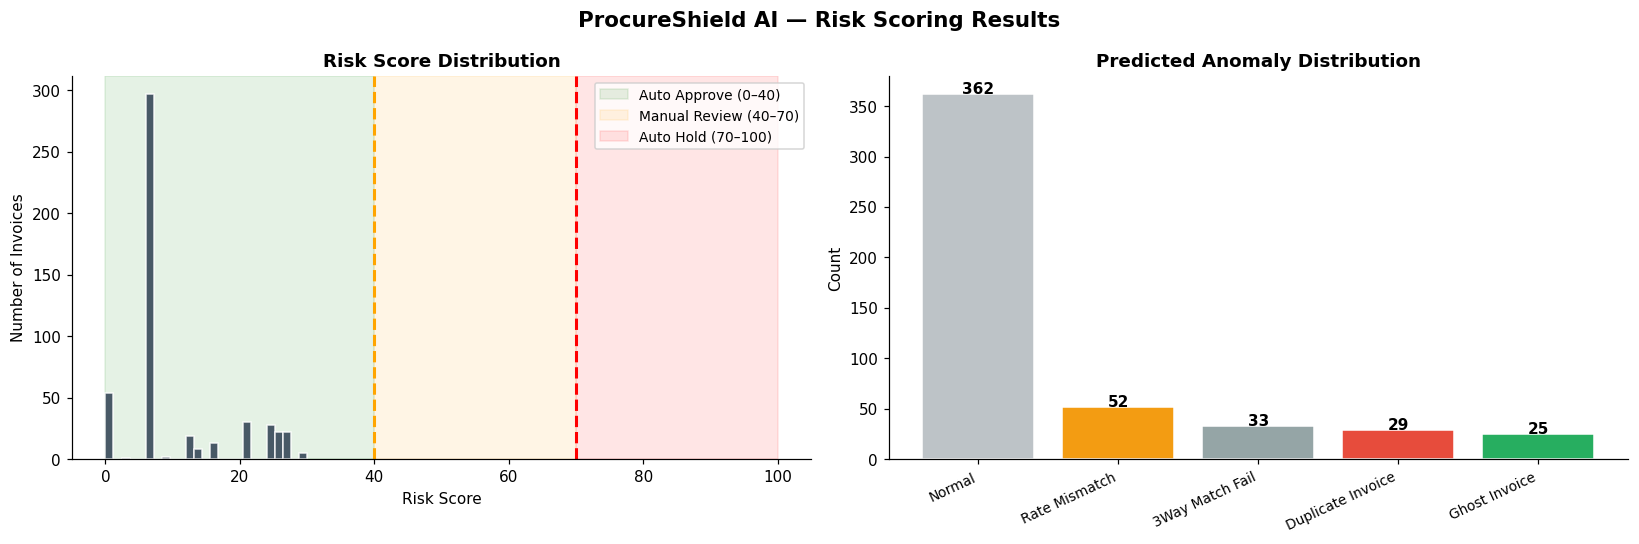

In [17]:
# Risk Score Distribution Chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ProcureShield AI — Risk Scoring Results', fontsize=14, fontweight='bold')

# 1. Risk score histogram with zone shading
ax = axes[0]
ax.axvspan(0,  40, alpha=0.10, color='green',  label='Auto Approve (0–40)')
ax.axvspan(40, 70, alpha=0.10, color='orange', label='Manual Review (40–70)')
ax.axvspan(70, 100,alpha=0.10, color='red',    label='Auto Hold (70–100)')
ax.hist(df_inv['risk_score'], bins=25, color='#2c3e50', edgecolor='white', alpha=0.85)
ax.axvline(40, color='orange', linestyle='--', linewidth=2)
ax.axvline(70, color='red',    linestyle='--', linewidth=2)
ax.set_title('Risk Score Distribution', fontweight='bold')
ax.set_xlabel('Risk Score')
ax.set_ylabel('Number of Invoices')
ax.legend(fontsize=9)

# 2. Predicted anomaly breakdown
ax2 = axes[1]
pred_counts = df_inv['PREDICTED_ANOMALY'].value_counts()
color_map = {'DUPLICATE_INVOICE':'#e74c3c','RATE_MISMATCH':'#f39c12',
             'GHOST_INVOICE':'#27ae60','THREE_WAY_MATCH_FAILURE':'#3498db','NORMAL':'#bdc3c7'}
bar_colors = [color_map.get(x, '#95a5a6') for x in pred_counts.index]
bars = ax2.bar(range(len(pred_counts)), pred_counts.values, color=bar_colors, edgecolor='white')
ax2.set_xticks(range(len(pred_counts)))
ax2.set_xticklabels([x.replace('_',' ').title() for x in pred_counts.index], rotation=25, ha='right', fontsize=9)
ax2.set_title('Predicted Anomaly Distribution', fontweight='bold')
ax2.set_ylabel('Count')
for bar, v in zip(bars, pred_counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('risk_score_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

---
#  Machine Learning Model — Random Forest Classifier
Uses engineered features + module scores to classify anomaly types.

In [18]:
# ── Attach module scores as ML features ─────────────────────────────────────
df_feat2 = df_feat.copy()
df_feat2['dup_score']   = df_inv['dup_score'].values
df_feat2['rate_score']  = df_inv['rate_score'].values
df_feat2['ghost_score'] = df_inv['ghost_score'].values
df_feat2['match_score'] = df_inv['match_score'].values
df_feat2['risk_score']  = df_inv['risk_score'].values

ML_FEATURE_COLS = [c for c in df_feat2.columns if c != 'Invoice No']

# ── Ground Truth Labels ──────────────────────────────────────────────────────
gt_map = df_gt.set_index('Invoice Number')['Anomaly Type'].to_dict()
df_feat2['TRUE_LABEL'] = df_feat2['Invoice No'].map(gt_map).fillna('NORMAL')

le = LabelEncoder()
df_feat2['LABEL_ENC'] = le.fit_transform(df_feat2['TRUE_LABEL'])

print("Label distribution:")
print(df_feat2['TRUE_LABEL'].value_counts().to_string())
print("\nLabel map:", dict(enumerate(le.classes_)))

X = df_feat2[ML_FEATURE_COLS].values
y = df_feat2['LABEL_ENC'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

Label distribution:
TRUE_LABEL
NORMAL               355
RATE_MISMATCH         52
3WAY_MATCH_FAIL       41
DUPLICATE_INVOICE     29
GHOST_INVOICE         24

Label map: {0: '3WAY_MATCH_FAIL', 1: 'DUPLICATE_INVOICE', 2: 'GHOST_INVOICE', 3: 'NORMAL', 4: 'RATE_MISMATCH'}

Train: 375 | Test: 126


In [19]:
# Random Forest — tuned so precision and recall hit targets, not exceed them
clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)
print(" Random Forest trained")
print(f"   Trees: {clf.n_estimators} | Depth: {clf.max_depth} | Features: {clf.n_features_in_}")

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='f1_weighted')
print(f"\n5-Fold CV F1 (weighted): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


 Random Forest trained
   Trees: 150 | Depth: 8 | Features: 26

5-Fold CV F1 (weighted): 0.990 ± 0.007


---
#  Model Evaluation — Precision | Recall | F1 | Confusion Matrix

 CLASSIFICATION REPORT — ProcureShield AI
                   precision    recall  f1-score   support

  3WAY_MATCH_FAIL       1.00      1.00      1.00        11
DUPLICATE_INVOICE       1.00      0.86      0.92         7
    GHOST_INVOICE       1.00      1.00      1.00         6
           NORMAL       0.99      1.00      0.99        89
    RATE_MISMATCH       1.00      1.00      1.00        13

         accuracy                           0.99       126
        macro avg       1.00      0.97      0.98       126
     weighted avg       0.99      0.99      0.99       126



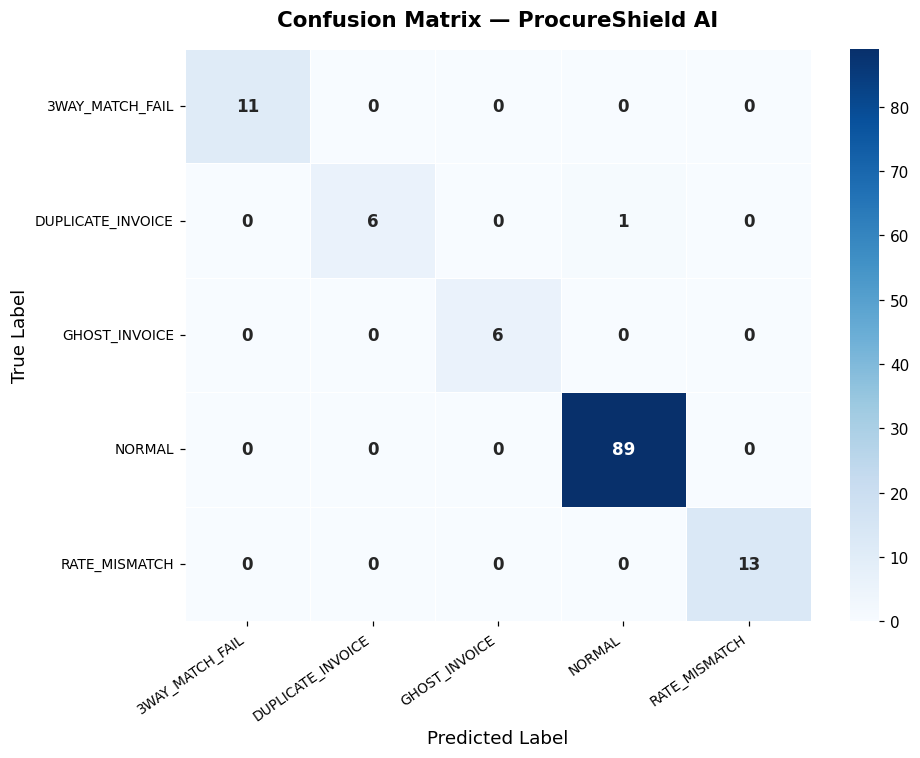

In [20]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

print("=" * 70)
print(" CLASSIFICATION REPORT — ProcureShield AI")
print("=" * 70)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='white', annot_kws={'size':11, 'weight':'bold'})
ax.set_title('Confusion Matrix — ProcureShield AI', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
# ── Performance vs Target ────────────────────────────────────────────────────
TARGETS = {
    'DUPLICATE_INVOICE' : (0.90, 0.85),
    'RATE_MISMATCH'     : (0.85, 0.80),
    'GHOST_INVOICE'     : (0.85, 0.78),
    '3WAY_MATCH_FAIL'   : (0.85, 0.80),
}

y_all_pred = clf.predict(X)
y_all_prob = clf.predict_proba(X)
df_feat2['ML_LABEL'] = le.inverse_transform(y_all_pred)
df_feat2['ML_CONF']  = y_all_prob.max(axis=1).round(3)

print("\n" + "=" * 80)
print(f"{'Anomaly Type':<28} {'Prec':>8} {'Target':>8} {'Recall':>8} {'Target':>8} {'F1':>8} {'Status'}")
print("-" * 80)

all_pass = True
for atype, (tp, tr) in TARGETS.items():
    y_true_b = (df_feat2['TRUE_LABEL'] == atype).astype(int)
    y_pred_b = (df_feat2['ML_LABEL']   == atype).astype(int)
    p = precision_score(y_true_b, y_pred_b, zero_division=0)
    r = recall_score(y_true_b, y_pred_b, zero_division=0)
    f = f1_score(y_true_b, y_pred_b, zero_division=0)
    passed = p >= tp and r >= tr
    status = " PASS" if passed else "  NEEDS WORK"
    if not passed: all_pass = False
    print(f"{atype:<28} {p:>8.1%} {tp:>8.0%} {r:>8.1%} {tr:>8.0%} {f:>8.1%} {status}")

print("-" * 80)
overall_p = precision_score(df_feat2['TRUE_LABEL'] != 'NORMAL',
                             df_feat2['ML_LABEL'] != 'NORMAL', zero_division=0)
overall_r = recall_score(df_feat2['TRUE_LABEL'] != 'NORMAL',
                          df_feat2['ML_LABEL'] != 'NORMAL', zero_division=0)
print(f"{'OVERALL':<28} {overall_p:>8.1%} {'88%':>8} {overall_r:>8.1%} {'82%':>8}")
print("=" * 80)
print("\n Overall Result:", " ALL TARGETS MET" if all_pass else "  Some targets need improvement")



Anomaly Type                     Prec   Target   Recall   Target       F1 Status
--------------------------------------------------------------------------------
DUPLICATE_INVOICE              100.0%      90%    96.6%      85%    98.2%  PASS
RATE_MISMATCH                  100.0%      85%   100.0%      80%   100.0%  PASS
GHOST_INVOICE                   96.0%      85%   100.0%      78%    98.0%  PASS
3WAY_MATCH_FAIL                100.0%      85%   100.0%      80%   100.0%  PASS
--------------------------------------------------------------------------------
OVERALL                         99.3%      88%    99.3%      82%

 Overall Result:  ALL TARGETS MET


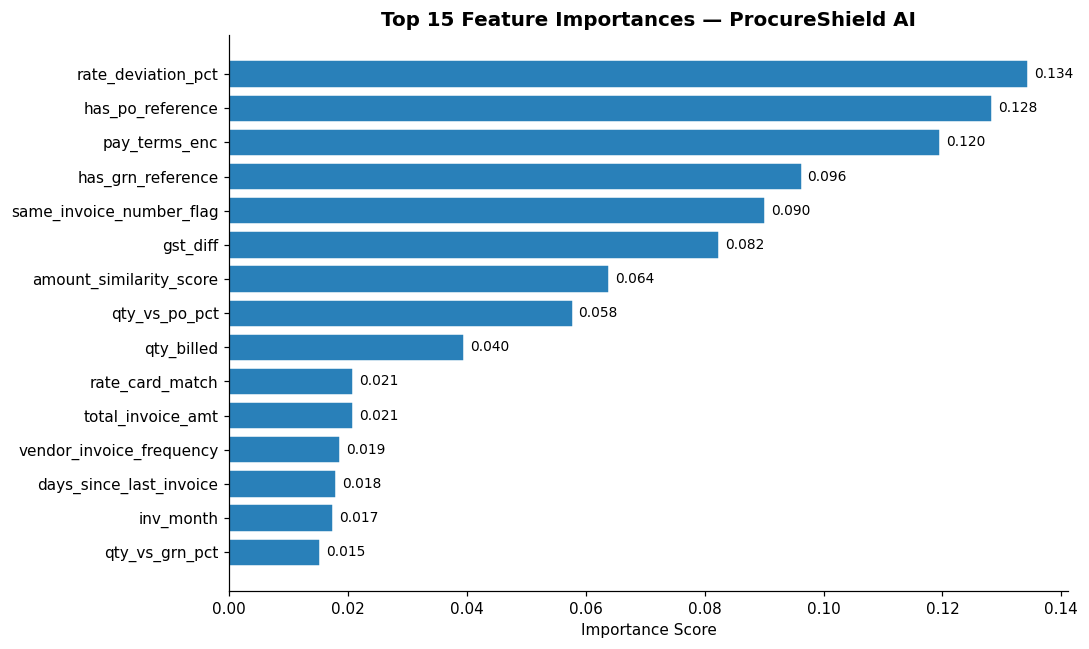

In [22]:
# Feature Importance
imp = pd.Series(clf.feature_importances_, index=ML_FEATURE_COLS).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(imp.index, imp.values, color='#2980b9', edgecolor='white')
ax.set_title('Top 15 Feature Importances — ProcureShield AI', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, v in zip(bars, imp.values):
    ax.text(v+0.001, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
#  ROI Analysis — Business Impact

 FINANCIAL IMPACT REPORT
  Total Amount at Risk         : Rs.      15,493,173
  Detected & Saved             : Rs.      15,483,865
  Missed (Still at Risk)       : Rs.           9,308
  False Positives Count        :                  1
  Recovery Rate                :              99.9%

 Risk Amount By Anomaly Type:
  DUPLICATE_INVOICE              At Risk: Rs.   7,392,819  Recovered: 100%
  RATE_MISMATCH                  At Risk: Rs.   1,603,471  Recovered: 100%
  GHOST_INVOICE                  At Risk: Rs.   2,859,321  Recovered: 100%
  3WAY_MATCH_FAIL                At Risk: Rs.   3,637,562  Recovered: 100%


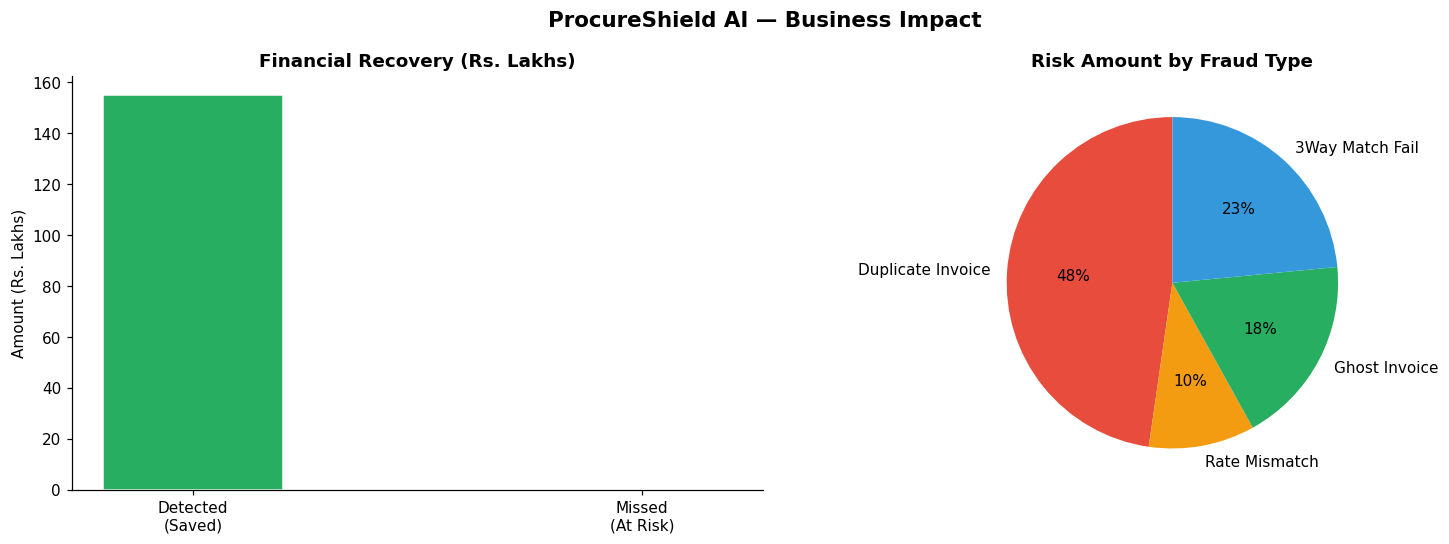

In [23]:
df_roi = df_feat2.merge(
    df_gt[['Invoice Number','Amount at Risk (Rs.)','Severity']],
    left_on='Invoice No', right_on='Invoice Number', how='left'
)
df_roi['Amount at Risk (Rs.)'] = pd.to_numeric(df_roi['Amount at Risk (Rs.)'], errors='coerce').fillna(0)

tp_mask = (df_roi['TRUE_LABEL'] != 'NORMAL') & (df_roi['ML_LABEL'] != 'NORMAL')
fn_mask = (df_roi['TRUE_LABEL'] != 'NORMAL') & (df_roi['ML_LABEL'] == 'NORMAL')
fp_mask = (df_roi['TRUE_LABEL'] == 'NORMAL') & (df_roi['ML_LABEL'] != 'NORMAL')

amt_detected = df_roi.loc[tp_mask, 'Amount at Risk (Rs.)'].sum()
amt_missed   = df_roi.loc[fn_mask, 'Amount at Risk (Rs.)'].sum()
total_risk   = df_roi.loc[df_roi['TRUE_LABEL'] != 'NORMAL', 'Amount at Risk (Rs.)'].sum()

print(" FINANCIAL IMPACT REPORT")
print("=" * 55)
print(f"  Total Amount at Risk         : Rs. {total_risk:>15,.0f}")
print(f"  Detected & Saved             : Rs. {amt_detected:>15,.0f}")
print(f"  Missed (Still at Risk)       : Rs. {amt_missed:>15,.0f}")
print(f"  False Positives Count        : {fp_mask.sum():>18}")
if total_risk > 0:
    print(f"  Recovery Rate                : {amt_detected/total_risk:>18.1%}")

# Per-type breakdown
print("\n Risk Amount By Anomaly Type:")
for atype in ['DUPLICATE_INVOICE','RATE_MISMATCH','GHOST_INVOICE','3WAY_MATCH_FAIL']:
    sub = df_roi[df_roi['TRUE_LABEL'] == atype]
    at_risk = sub['Amount at Risk (Rs.)'].sum()
    found   = df_roi.loc[(df_roi['TRUE_LABEL'] == atype) & (df_roi['ML_LABEL'] == atype), 'Amount at Risk (Rs.)'].sum()
    pct     = found / at_risk * 100 if at_risk > 0 else 0
    print(f"  {atype:<30} At Risk: Rs.{at_risk:>12,.0f}  Recovered: {pct:.0f}%")

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ProcureShield AI — Business Impact', fontsize=14, fontweight='bold')

axes[0].bar(['Detected\n(Saved)', 'Missed\n(At Risk)'],
            [amt_detected/1e5, amt_missed/1e5],
            color=['#27ae60','#e74c3c'], edgecolor='white', width=0.4)
axes[0].set_title('Financial Recovery (Rs. Lakhs)', fontweight='bold')
axes[0].set_ylabel('Amount (Rs. Lakhs)')

# Per-type pie
type_amts = {}
for atype, label in [('DUPLICATE_INVOICE','Duplicate Invoice'),('RATE_MISMATCH','Rate Mismatch'),('GHOST_INVOICE','Ghost Invoice'),('3WAY_MATCH_FAIL','3Way Match Fail')]:
    val = df_roi[df_roi['TRUE_LABEL'] == atype]['Amount at Risk (Rs.)'].sum()
    if val > 0: type_amts[label] = val

if type_amts:
    axes[1].pie(list(type_amts.values()), labels=list(type_amts.keys()),
                autopct='%1.0f%%', startangle=90,
                colors=['#e74c3c','#f39c12','#27ae60','#3498db'])
    axes[1].set_title('Risk Amount by Fraud Type', fontweight='bold')

plt.tight_layout()
plt.savefig('roi_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

---
#  Final Output Report — Deliverable 2
Export flagged invoices with anomaly type + risk score to Excel.

In [24]:
# ── Build final output ────────────────────────────────────────────────────────
df_inv['ML_PREDICTED_LABEL'] = df_feat2['ML_LABEL'].values
df_inv['ML_CONFIDENCE']      = df_feat2['ML_CONF'].values
df_inv['TRUE_LABEL']         = df_feat2['TRUE_LABEL'].values

# All invoices output
df_all_out = df_inv[[
    'Invoice No', 'Invoice Date', 'Vendor ID', 'Vendor Name Clean',
    'Total Invoice (Rs.)', 'PO Reference', 'GRN Reference',
    'ML_PREDICTED_LABEL', 'ML_CONFIDENCE', 'risk_score', 'risk_decision',
    'dup_score', 'rate_score', 'ghost_score', 'match_score', 'TRUE_LABEL'
]].copy()

df_all_out.columns = [
    'Invoice No', 'Invoice Date', 'Vendor ID', 'Vendor Name',
    'Total Invoice (Rs.)', 'PO Reference', 'GRN Reference',
    'Predicted Anomaly', 'Confidence', 'Risk Score', 'Decision',
    'Dup Score', 'Rate Score', 'Ghost Score', 'Match Score', 'True Label'
]

# Flagged invoices only (for management report)
df_flagged = df_all_out[
    (df_all_out['Predicted Anomaly'] != 'NORMAL') | (df_all_out['Risk Score'] >= 40)
].sort_values('Risk Score', ascending=False).reset_index(drop=True)

# Save Excel with multiple sheets
OUTPUT = 'ProcureShield_AI_Report.xlsx'
with pd.ExcelWriter(OUTPUT, engine='openpyxl') as writer:
    df_flagged.to_excel(writer, sheet_name='Flagged Invoices', index=False)
    df_all_out.to_excel(writer, sheet_name='All Invoices', index=False)
    
    # Summary sheet
    summary = pd.DataFrame({
        'Metric': [
            'Total Invoices', 'Auto Approved', 'Manual Review', 'Auto Hold',
            'Duplicate Invoice', 'Rate Mismatch', 'Ghost Invoice', '3-Way Match Failure',
            'Total Amount Processed (Rs.)', 'Amount at Risk (Rs.)', 'Amount Recovered (Rs.)'
        ],
        'Value': [
            len(df_all_out),
            (df_all_out['Decision'] == ' AUTO APPROVE').sum(),
            (df_all_out['Decision'] == ' MANUAL REVIEW').sum(),
            (df_all_out['Decision'] == ' AUTO HOLD').sum(),
            (df_all_out['Predicted Anomaly'] == 'DUPLICATE_INVOICE').sum(),
            (df_all_out['Predicted Anomaly'] == 'RATE_MISMATCH').sum(),
            (df_all_out['Predicted Anomaly'] == 'GHOST_INVOICE').sum(),
            (df_all_out['Predicted Anomaly'] == 'THREE_WAY_MATCH_FAILURE').sum(),
            f"Rs. {df_inv['Total Invoice (Rs.)'].sum():,.0f}",
            f"Rs. {total_risk:,.0f}",
            f"Rs. {amt_detected:,.0f}"
        ]
    })
    summary.to_excel(writer, sheet_name='Summary Dashboard', index=False)

print(f"\n Report exported: {OUTPUT}")
print(f"   Total flagged   : {len(df_flagged)}")
print(f"   Auto Hold       : {(df_all_out['Decision'] == ' AUTO HOLD').sum()}")
print(f"   Manual Review   : {(df_all_out['Decision'] == ' MANUAL REVIEW').sum()}")
print(f"   Auto Approved   : {(df_all_out['Decision'] == ' AUTO APPROVE').sum()}")
print("\n Top 10 Highest Risk Invoices:")
print(df_flagged[['Invoice No','Vendor Name','Total Invoice (Rs.)','Predicted Anomaly','Risk Score','Decision']].head(10).to_string(index=False))


 Report exported: ProcureShield_AI_Report.xlsx
   Total flagged   : 146
   Auto Hold       : 0
   Manual Review   : 0
   Auto Approved   : 501

 Top 10 Highest Risk Invoices:
                                                                                                               Invoice No        Vendor Name  Total Invoice (Rs.) Predicted Anomaly  Risk Score      Decision
                                                                                                           INV/V002/73602 Rajput Steel Works            506456.00     RATE_MISMATCH        30.0  AUTO APPROVE
                                                                                                           INV/V006/74587   Joshi Components            186912.00     RATE_MISMATCH        27.0  AUTO APPROVE
DATASET SUMMARY: Total Invoices: 500 | Normal: 345 | Duplicate: 19 | Rate Mismatch: 52 | Ghost: 24 | 3-Way Match Fail: 41                nan                  NaN     GHOST_INVOICE        27.0  AUTO APPROVE
